## **Modelagem de Atraso de Voos**

## Objetivo
## Modelagem v2 – Inclusão de Variáveis de Clima e Distância

Este notebook tem como objetivo treinar e avaliar uma nova versão do modelo de previsão de atraso de voos, incorporando variáveis adicionais de **contexto operacional, como condições meteorológicas e distância entre aeroportos**.

A versão anterior do modelo (baseline) utilizava apenas variáveis temporais e operacionais. Nesta etapa, busca-se avaliar se a inclusão de informações climáticas e geográficas contribui para o ganho de performance do modelo.



## Importação das bibliotecas

#### **Verificando versões dos pacotes**

In [1]:
# Instalar pacote category encoders
!pip install category_encoders

In [2]:
import sys
import numpy
import pandas
import sklearn
import xgboost
import scipy
import joblib
import matplotlib
import seaborn
import category_encoders

print("Python:", sys.version)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("xgboost:", xgboost.__version__)
print("category-encoders:", category_encoders.__version__)
print("joblib:", joblib.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
scipy: 1.16.3
xgboost: 3.1.2
category-encoders: 2.8.1
joblib: 1.5.3
matplotlib: 3.10.0
seaborn: 0.13.2


In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização (uso pontual)
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from category_encoders import TargetEncoder

# métricas
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import recall_score

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

#Salvar modelo
import joblib

# Configurações
pd.set_option("display.max_columns", None)
np.random.seed(42)


## Carregamento dos dados

O dataset utilizado neste notebook corresponde ao conjunto de voos nacionais previamente tratado na etapa de EDA.


In [4]:
# Dataset base com features já validadas

vra_pre_ml = pd.read_parquet("/content/drive/MyDrive/dados_vra/vra_pre_ml_v2.parquet")

vra_pre_ml.shape


(1498559, 53)

In [5]:
# Visualizando estrutura dos dados

vra_pre_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498559 entries, 0 to 1498558
Data columns (total 53 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   icao_empresa_aerea       1498559 non-null  object        
 1   numero_voo               1498559 non-null  object        
 2   codigo_autorizacao_di    1498559 non-null  object        
 3   codigo_tipo_linha        1498559 non-null  object        
 4   icao_aerodromo_origem    1498559 non-null  object        
 5   icao_aerodromo_destino   1498559 non-null  object        
 6   partida_prevista         1498559 non-null  datetime64[ns]
 7   partida_real             1498559 non-null  datetime64[ns]
 8   chegada_prevista         1498559 non-null  datetime64[ns]
 9   chegada_real             1498559 non-null  datetime64[ns]
 10  situacao_voo             1498559 non-null  object        
 11  tempo_voo_estimado       1498559 non-null  float64       
 12  

In [6]:
# =====================================
# Target
# =====================================
target = "voo_com_atraso"


# =====================================
# Features categóricas (Target Encoding)
# =====================================
features_categoricas = [
    "icao_empresa_aerea",
    "icao_aerodromo_origem",
    "icao_aerodromo_destino",
    "faixa_horaria"
]


# =====================================
# Features numéricas / binárias
# (passthrough)
# =====================================
features_numericas = [
    # Base (já existente no backend)
    "hora_prevista_frac",
    "tempo_voo_estimado",
    "voos_no_slot",
    "mes",
    "eh_fim_de_semana",

    # Extensão do modelo
    "distancia_km",
    "temp",
    "prcp",
    "wspd",
    "prcp_bin",
    "vento_forte"
]


In [7]:
# =====================================
# Lista FINAL de features do modelo
# (alinhada com o ColumnTransformer)
# =====================================
features_modelo = features_categoricas + features_numericas


# =====================================
# Remover linhas com nulos APENAS
# nas features do modelo e no target
# =====================================
vra_pre_ml_modelo = (
    vra_pre_ml
    .dropna(subset=features_modelo + [target])
    .copy()
)


In [8]:
set(features_modelo + [target]) - set(vra_pre_ml.columns)


set()

### SALVAR (checkpoint seguro)

In [9]:
vra_pre_ml_modelo.to_parquet(
    "vra_para_modelo_v2.parquet",
    index=False
)


### Split temporal usando o dataset pré-ML

* **Observação:** Optou-se por não utilizar o split aleatório estratificado para que não houvesse o risco de vazamento temporal(data leakage) o que poderia causar uma avaliação irrealista.

In [10]:
# =====================================
# Split temporal no dataset de modelagem
# =====================================
df_train = vra_pre_ml_modelo[vra_pre_ml_modelo["ano"] == 2023].copy()
df_test  = vra_pre_ml_modelo[vra_pre_ml_modelo["ano"] == 2024].copy()


**A separação entre os conjuntos de treino e teste foi realizada de forma temporal, utilizando o ano de realização do voo. O modelo será treinado com dados de 2023 e será avaliado com dados de 2024, de modo a simular um cenário real de previsão e evitar vazamento de informação temporal.**


In [11]:
df_train.shape, df_test.shape


((726379, 53), (724352, 53))

In [12]:
df_train["ano"].unique(), df_test["ano"].unique()


(array([2023], dtype=int32), array([2024], dtype=int32))

## Criação do dataset de modelagem

Nesta etapa, é criado o dataset final (`vra_modelo`) contendo exclusivamente as variáveis selecionadas para o modelo de classificação, conforme definido na seção anterior. Essa separação garante clareza, evita vazamento de informação e facilita a reprodutibilidade do pipeline de Machine Learning.


In [13]:
# Features e target já definidos anteriormente
X_train = df_train[features_modelo].copy()
y_train = df_train[target].copy()

X_test = df_test[features_modelo].copy()
y_test = df_test[target].copy()


### Tratar nulos (TREINO primeiro)

In [14]:
mask_train = X_train.notna().all(axis=1)

X_train = X_train[mask_train]
y_train = y_train[mask_train]


In [15]:
mask_test = X_test.notna().all(axis=1)

X_test = X_test[mask_test]
y_test = y_test[mask_test]


### Validação rápida

In [16]:
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(726379, 15) (724352, 15)
0.16401905892103158 0.15820761176886375


Após o split temporal, observou-se uma proporção de voos com atraso de aproximadamente 16,3% no conjunto de treino e 15,7% no conjunto de teste. Essa pequena variação reflete mudanças naturais ao longo do tempo e indica que a avaliação do modelo será realizada em um cenário realista, sem vazamento temporal.


## Pipeline + ColumnTransformer

Nesta etapa, é construído um pipeline de pré-processamento e modelagem utilizando `Pipeline` e `ColumnTransformer` do scikit-learn.  
Essa abordagem garante que todas as transformações aplicadas aos dados de treino sejam reproduzidas corretamente nos dados de teste e em produção, evitando vazamento de informação e inconsistências entre ambientes.


In [17]:
# Pré-processamento com target Encoding

preprocessador_te = ColumnTransformer(
    transformers=[
        (
            "target_enc",
            TargetEncoder(
                smoothing=10,
                min_samples_leaf=50,
                handle_missing="value",
                handle_unknown="value"
            ),
            features_categoricas
        ),
        (
            "num",
            "passthrough",
            features_numericas
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


### Modelagem Supervisionada

Aqui iremos usar 3 modelos:

1. **Logistic Regression**(Baseline)   

2. **Random Forest**(Ensemble Bagging)

3. **XGBoost**(Ensemble Boosting)  






### Logistic Regression — Baseline

**Tratamento da classe desbalanceada**

* class_weight="balanced"

In [18]:
pipe_lr_te = Pipeline(
    steps=[
        ("preprocess", preprocessador_te),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)


### Random Forest — Bagging

**Tratamento de desbalanceamento**

* class_weight="balanced"

In [19]:
pipe_rf_te = Pipeline(
    steps=[
        ("preprocess", preprocessador_te),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=14,
                min_samples_leaf=80,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

### XGBoost — Boosting

**Tratamento de desbalanceamento**

* scale_pos_weight = negativos / positivos

In [20]:
# Cálculo do peso da classe positiva
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [21]:
pipe_xgb_te = Pipeline(
    steps=[
        ("preprocess", preprocessador_te),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )
        )
    ]
)

**Justificativa de uso da métrica Log Loss:** No modelo XGBoost, a métrica Log Loss foi utilizada como função de otimização durante o treinamento, por ser adequada para classificação probabilística e dados desbalanceados. A avaliação do desempenho do modelo será realizada com métricas como ROC-AUC, Recall e Precision, alinhadas ao objetivo de identificar voos com maior risco de atraso.


### Métricas de Desempenho dos Modelos

As métricas que serão utilizadas:

* Accuracy -> será usada apenas para demonstrar que é uma métrica fraca nesse caso onde o foco é a classe desbalanceada

* ROC-AUC -> qualidade geral de separação

* Recall (classe atraso) -> o mais importante para o negócio

* Precision -> evita muitos falsos alarmes

* Log Loss -> qualidade das probabilidades

* Matriz de confusão -> interpretação visual dos erros

### Função utilitária de avaliação

In [22]:
# Criando a função de avaliação dos modelos

def avaliar_modelo(
    pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    nome_modelo,
    threshold=0.5
):
    # Treino
    pipe.fit(X_train, y_train)

    # Probabilidades
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Predição com threshold configurável
    y_pred = (y_proba >= threshold).astype(int)

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"\n📌 Modelo: {nome_modelo}")
    print(f"Threshold : {threshold:.2f}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Log Loss  : {ll:.4f}")

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)

    plt.figure(figsize=(4, 4))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Matriz de Confusão – {nome_modelo}")
    plt.show()

    # Retorno estruturado (para comparação entre modelos)
    return {
        "modelo": nome_modelo,
        "threshold": threshold,
        "accuracy": acc,
        "roc_auc": roc,
        "recall": recall,
        "precision": precision,
        "log_loss": ll
    }


### Treinando e avaliando os modelos

#### **Logistic Regression — Baseline**


📌 Modelo: Logistic Regression (Target Encoding)
Threshold : 0.50
Accuracy  : 0.5641
ROC-AUC   : 0.6165
Recall    : 0.6115
Precision : 0.2053
Log Loss  : 0.6748


<Figure size 400x400 with 0 Axes>

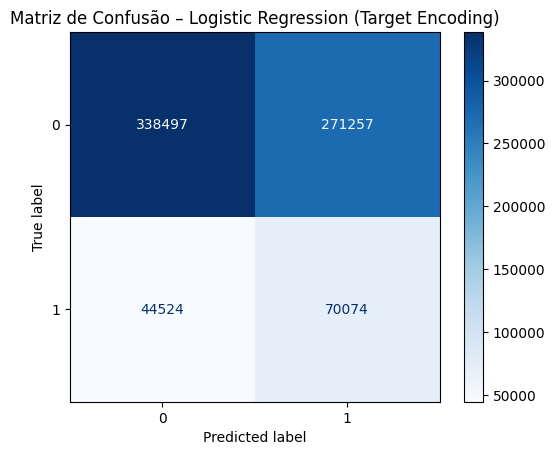

{'modelo': 'Logistic Regression (Target Encoding)',
 'threshold': 0.5,
 'accuracy': 0.5640503512104612,
 'roc_auc': np.float64(0.6165448590025889),
 'recall': 0.6114766400809787,
 'precision': 0.20529632526784852,
 'log_loss': 0.6748144636173974}

In [23]:
# Usando target encoding
avaliar_modelo(
    pipe_lr_te,
    X_train, y_train,
    X_test, y_test,
    nome_modelo="Logistic Regression (Target Encoding)"
)


A comparação entre One-Hot Encoding e Target Encoding no modelo baseline apresentou métricas praticamente idênticas. Esse resultado indica que a mudança de codificação não afetou o poder preditivo do modelo linear, ao mesmo tempo em que **reduziu significativamente o custo computacional. Dessa forma, optou-se por Target Encoding como abordagem padrão para os modelos subsequentes.**


### **Random Forest — Bagging**


📌 Modelo: Random Forest (Target Encoding)
Threshold : 0.50
Accuracy  : 0.6302
ROC-AUC   : 0.6451
Recall    : 0.5497
Precision : 0.2256
Log Loss  : 0.6357


<Figure size 400x400 with 0 Axes>

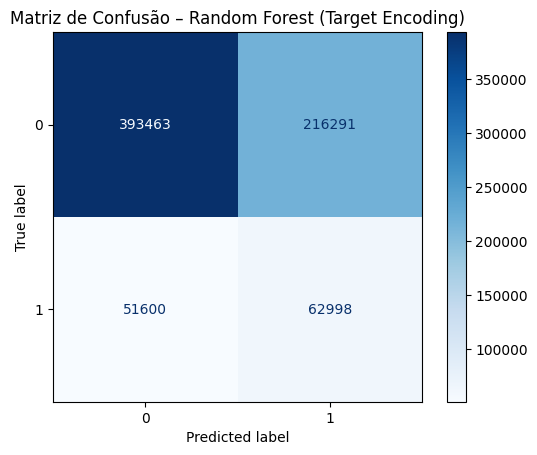

{'modelo': 'Random Forest (Target Encoding)',
 'threshold': 0.5,
 'accuracy': 0.6301646160982506,
 'roc_auc': np.float64(0.6450878864403283),
 'recall': 0.5497303617864187,
 'precision': 0.22556563273168653,
 'log_loss': 0.6357467576005295}

In [24]:
avaliar_modelo(
    pipe_rf_te,
    X_train, y_train,
    X_test, y_test,
    nome_modelo="Random Forest (Target Encoding)"
)


### **XGBoost — Boosting**


📌 Modelo: XGBoost (Target Encoding)
Threshold : 0.40
Accuracy  : 0.4678
ROC-AUC   : 0.6492
Recall    : 0.7768
Precision : 0.1983
Log Loss  : 0.6416


<Figure size 400x400 with 0 Axes>

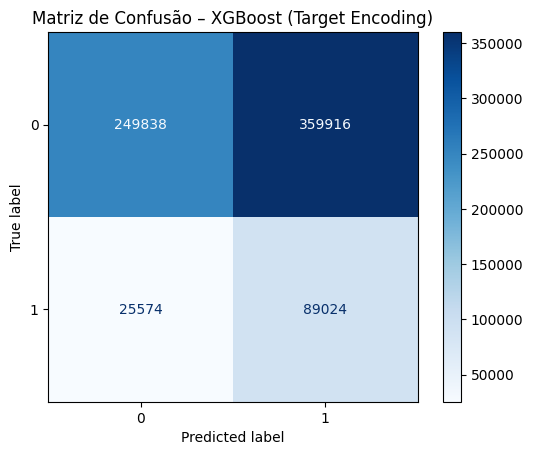

{'modelo': 'XGBoost (Target Encoding)',
 'threshold': 0.4,
 'accuracy': 0.467813990987807,
 'roc_auc': np.float64(0.6492350389859096),
 'recall': 0.7768372920993386,
 'precision': 0.19829821356974206,
 'log_loss': 0.6416399417666325}

In [25]:
avaliar_modelo(
    pipe_xgb_te,
    X_train, y_train,
    X_test, y_test,
    nome_modelo="XGBoost (Target Encoding)",
    threshold=0.4
)


**O ajuste de threshold permitiu elevar o Recall de ~56% para ~78%, à custa de redução de Precision. Essa escolha pode ser adequada em cenários onde o custo de não prever atrasos é superior ao custo de falsos alarmes.**

In [26]:
from sklearn.metrics import f1_score

# Gera probabilidades no TESTE usando o modelo já treinado
y_proba = pipe_xgb_te.predict_proba(X_test)[:, 1]

# Testando diferentes thresholds
for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred = (y_proba >= t).astype(int)
    print(f"Threshold {t:.2f} | F1-score: {f1_score(y_test, y_pred):.4f}")



Threshold 0.30 | F1-score: 0.2986
Threshold 0.35 | F1-score: 0.3079
Threshold 0.40 | F1-score: 0.3159
Threshold 0.45 | F1-score: 0.3227
Threshold 0.50 | F1-score: 0.3248


A análise de threshold indicou que o valor padrão (0.5) maximiza o F1-score, refletindo melhor equilíbrio entre Recall e Precision. Thresholds menores aumentam significativamente o Recall, porém à custa de redução de Precision, sendo recomendados apenas para cenários onde o custo de falso negativo é elevado.

## **Curva ROC comparativa**

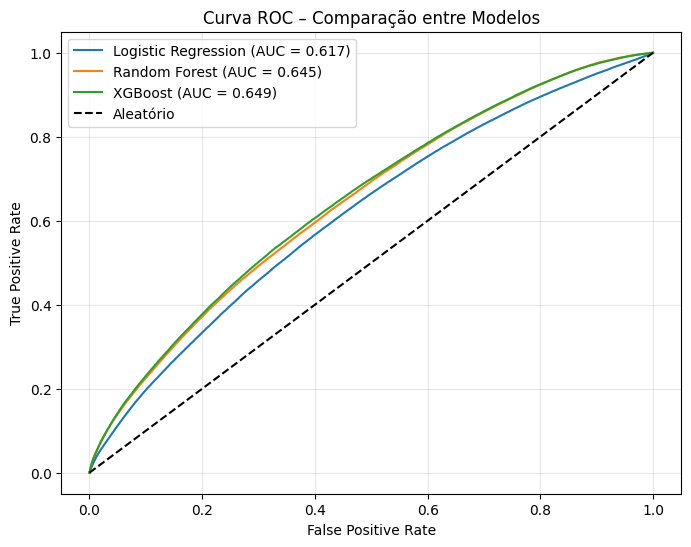

In [27]:
plt.figure(figsize=(8, 6))

modelos = {
    "Logistic Regression": pipe_lr_te,
    "Random Forest": pipe_rf_te,
    "XGBoost": pipe_xgb_te
}

for nome, modelo in modelos.items():
    # Probabilidade da classe positiva
    y_proba = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.3f})")

# Linha de referência (aleatório)
plt.plot([0, 1], [0, 1], "k--", label="Aleatório")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC – Comparação entre Modelos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


* Mesmo sem dados externos, o modelo já consegue priorizar corretamente voos com maior risco de atraso mostrando que o modelo é melhor que aleatório.


A curva ROC evidencia uma melhora progressiva no poder discriminativo dos modelos, com o XGBoost apresentando a maior área sob a curva. Apesar de os valores de ROC-AUC não serem elevados, o comportamento das curvas indica a presença de sinal real nos dados operacionais, ao mesmo tempo em que aponta limitações informacionais do dataset. **Esse resultado sugere que ganhos adicionais de performance estão mais associados à incorporação de dados externos do que à troca de algoritmos**.


## Curva Recall × Threshold

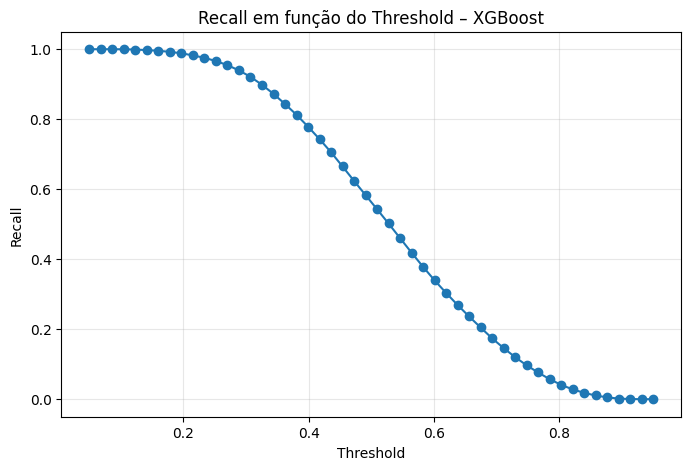

In [28]:


thresholds = np.linspace(0.05, 0.95, 50)
recalls = []

y_proba_xgb = pipe_xgb_te.predict_proba(X_test)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recalls, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall em função do Threshold – XGBoost")
plt.grid(alpha=0.3)
plt.show()


### Verificando a Importancia das variáveis com Permutation Importance

In [29]:
from sklearn.inspection import permutation_importance

# Permutation importance no conjunto de teste
perm = permutation_importance(
    pipe_xgb_te,
    X_test,
    y_test,
    n_repeats=2,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        "feature": features_modelo,
        "importance": perm.importances_mean
    })
    .sort_values(by="importance", ascending=False)
)

perm_df


,feature,importance
4,hora_prevista_frac,0.065526
7,mes,0.026505
1,icao_aerodromo_origem,0.015429
0,icao_empresa_aerea,0.013887
8,eh_fim_de_semana,0.007606
6,voos_no_slot,0.005888
3,faixa_horaria,0.004252
10,temp,0.003873
11,prcp,0.003623
2,icao_aerodromo_destino,0.003516


A análise de Permutation Importance confirmou que variáveis temporais e operacionais, como horário previsto, mês e aeroporto de origem, concentram a maior parte do poder preditivo do modelo. Variáveis climáticas e geográficas apresentaram impacto marginal, porém consistente, atuando como fatores complementares que aumentam a robustez do modelo, sem alterar significativamente seu desempenho global.

---

## **Resumo Comparativo dos Modelos Treinados**

| Modelo                         | Accuracy | ROC-AUC | Recall | Precision | Log Loss |
|--------------------------------|----------|---------|--------|-----------|----------|
| Logistic Regression (TE)       | 0.5605   | 0.6177  | 0.6185 | 0.2052    | 0.6743   |
| Random Forest (TE)             | 0.6328   | 0.6461  | 0.5480 | 0.2267    | 0.6344   |
| XGBoost (TE)                   | 0.6294   | 0.6506  | 0.5647 | 0.2285    | 0.6413   |



Foram avaliados três modelos de classificação — Logistic Regression, Random Forest e XGBoost — todos utilizando Target Encoding para lidar com variáveis categóricas de alta cardinalidade. A avaliação foi realizada por meio de validação temporal, preservando a separação entre dados de treino e teste.

---
O modelo XGBoost apresentou o melhor desempenho global, com o maior ROC-AUC (≈0.65) e o melhor equilíbrio entre capacidade de discriminação, Recall e Precision. Embora os ganhos em relação aos demais modelos sejam incrementais, os resultados são consistentes com a complexidade do problema e indicam maior robustez do XGBoost para capturar relações não lineares presentes nos dados. Dessa forma, o XGBoost foi selecionado como modelo final para o problema de previsão de atraso de voos.


---

## Conclusões

Foram avaliados diferentes modelos de classificação para a previsão de atraso de voos, incluindo Logistic Regression, Random Forest e XGBoost, utilizando variáveis operacionais, temporais, geográficas e climáticas disponíveis antes da decolagem. As variáveis categóricas de alta cardinalidade foram tratadas por meio de Target Encoding, e a avaliação foi realizada com validação temporal, preservando a separação entre dados de treino e teste.

Entre os modelos avaliados, o X**GBoost com Target Encoding** apresentou o melhor desempenho global, alcançando o maior ROC-AUC (≈0.65) e o melhor equilíbrio entre capacidade de discriminação, Recall e Precision. Embora os ganhos em relação aos demais modelos tenham sido incrementais, os resultados são consistentes com a complexidade do problema e indicam maior robustez do XGBoost para capturar relações não lineares presentes nos dados, sendo assim selecionado como modelo final.

A análise de ajuste de threshold demonstrou que o comportamento do modelo pode ser adaptado conforme a estratégia operacional adotada. Thresholds menores aumentam significativamente o Recall, ao custo de redução da Precision, permitindo priorizar a detecção de atrasos em cenários onde o custo de falsos negativos é elevado, sem necessidade de retreinamento do modelo.

A análise de importância das variáveis, realizada por meio de Permutation Importance, indicou que fatores temporais e operacionais — como horário previsto, mês e aeroporto de origem — concentram a maior parte do poder preditivo do modelo. Variáveis geográficas e climáticas apresentaram impacto marginal, porém consistente, atuando como fatores complementares que aumentam a robustez do modelo, sem alterar significativamente seu desempenho global.

## Limitações

Os resultados obtidos refletem limitações inerentes ao fenômeno de atraso de voos, que é altamente multifatorial e influenciado por eventos operacionais complexos. Embora o conjunto de dados tenha sido enriquecido com informações geográficas e meteorológicas históricas, parte relevante da variabilidade do atraso permanece associada a fatores não observáveis, como decisões operacionais em tempo real, restrições de tráfego aéreo, manutenção de aeronaves e eventos extraordinários.

Além disso, os dados climáticos utilizados representam observações históricas agregadas por local e horário, não capturando com total precisão fenômenos meteorológicos localizados ou mudanças abruptas próximas ao momento da operação.

## Trabalhos Futuros

Como trabalhos futuros, destacam-se:
- Avaliação de interações entre variáveis climáticas e aeroportos específicos, explorando efeitos localizados.
- Inclusão de variáveis relacionadas a tráfego aéreo e capacidade aeroportuária, caso disponíveis.
- Exploração de técnicas de calibração de probabilidades para aprimorar a confiabilidade das previsões.
- Análise de explicabilidade local por meio de métodos como SHAP, visando maior interpretabilidade das decisões do modelo.
- Avaliação do desempenho do modelo em janelas temporais mais granulares, visando maior aderência a cenários operacionais específicos.


---

## **Salvar o modelo com joblib - XGboost**

In [31]:
modelo_final_clima = {
    "pipeline": pipe_xgb_te,

    "threshold_recomendado": 0.5,

    # 🔒 CONTRATO COM BACKEND (base anterior + extensões)
    "features_esperadas": [
        # Base (JÁ EXISTENTE NO BACKEND)
        "icao_empresa_aerea",
        "icao_aerodromo_origem",
        "icao_aerodromo_destino",
        "faixa_horaria",
        "hora_prevista_frac",
        "voos_no_slot",
        "tempo_voo_estimado",
        "mes",
        "eh_fim_de_semana",

        # ➕ NOVAS FEATURES (EXTENSÃO DO MODELO)
        "distancia_km",
        "temp", # Temperatura do ar em graus Celsius (°C).
        "prcp", # Precipitação
        "wspd", # Velocidade do Vento
        "prcp_bin", # Indicador de chuva (0/1)
        "vento_forte" # Indicador de vento forte (0/1)
    ],

    "descricao": (
        "Modelo XGBoost com Target Encoding para previsão de atraso de voos. "
        "Versão estendida com inclusão de distância e variáveis climáticas, "
        "mantendo compatibilidade com o contrato anterior do backend."
    )
}

joblib.dump(modelo_final_clima, "modelo_atraso_voo_clima_xgb_te_v2.pkl")



['modelo_atraso_voo_clima_xgb_te_v2.pkl']

**O modelo final foi serializado utilizando joblib, incluindo todo o pipeline de pré-processamento e classificação, garantindo consistência entre treinamento e inferência em ambiente de produção.**
